# Step 1 — Data Preparation


In [1]:
# ============================================================
#   CELL 1 — RUN THIS EVERY SESSION
# ============================================================
import os, torch
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
BASE      = "/content/drive/MyDrive/chest_xray_project"
DATA_PATH = f"{BASE}/data"
WEIGHTS   = f"{BASE}/weights"
REPORTS   = f"{BASE}/reports"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create folders if they don't exist (safe to re-run)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(WEIGHTS,   exist_ok=True)
os.makedirs(REPORTS,   exist_ok=True)

print(f"✅ Drive  : Mounted")
print(f"✅ Device : {DEVICE}")
print(f"✅ Base   : {BASE}")
print(f"✅ Folders: {os.listdir(BASE)}")

Mounted at /content/drive
✅ Drive  : Mounted
✅ Device : cpu
✅ Base   : /content/drive/MyDrive/chest_xray_project
✅ Folders: ['data', 'weights', 'reports']


In [2]:
# ============================================================
#   CELL 2 — DOWNLOAD & LOCATE DATASET
# ============================================================
import kagglehub, os

# Download dataset (caches in /root/.cache/kaggle — no Drive needed)
print("⏳ Downloading COVID-19 Radiography Database...")
dataset_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
print(f"✅ Raw Dataset Path: {dataset_path}")

# Check what's inside
print(f"\n📁 Initial Contents: {os.listdir(dataset_path)}")

# Fix nested folder if present
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")
    print(f"📂 Went one level deeper...")

# Final path
print(f"\n✅ Final Dataset Path: {dataset_path}")
print(f"📁 Final Contents: {os.listdir(dataset_path)}")

# Update DATA_PATH to point here
DATA_PATH = dataset_path

# Class-wise image count
print("\n📊 Class Image Counts:")
classes = [f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f))]
for cls in sorted(classes):
    img_folder = os.path.join(DATA_PATH, cls, "images")
    if os.path.exists(img_folder):
        print(f"   {cls}: {len(os.listdir(img_folder))} images")

⏳ Downloading COVID-19 Radiography Database...
Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
✅ Raw Dataset Path: /kaggle/input/covid19-radiography-database

📁 Initial Contents: ['COVID-19_Radiography_Dataset']
📂 Went one level deeper...

✅ Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
📁 Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']

📊 Class Image Counts:
   COVID: 3616 images
   Lung_Opacity: 6012 images
   Normal: 10192 images
   Viral Pneumonia: 1345 images


In [3]:
# ============================================================
#   CELL 3 (FIXED) — DATA LOADING WITH AUGMENTATION
# ============================================================
import os, torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# ── Transforms ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Custom Dataset (images/ only, no masks) ───────────────────
class COVIDDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform
        self.classes   = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and "mask" not in d.lower()
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            img_dir = os.path.join(root, cls, "images")
            if not os.path.exists(img_dir):
                img_dir = os.path.join(root, cls)
            for fname in os.listdir(img_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(img_dir, fname), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

# ── Build Dataset & Splits ────────────────────────────────────
full_dataset = COVIDDataset(root=DATA_PATH, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# ── Attractive Output ─────────────────────────────────────────
from collections import Counter

# Count per class
label_counts = Counter([s[1] for s in full_dataset.samples])

print("╔══════════════════════════════════════════════════════╗")
print("║         🫁  COVID-19 RADIOGRAPHY DATASET             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📁 Path     : ...{DATA_PATH[-35:]}  ║")
print(f"║  🖼️  Total    : {total:,} images{' ' * (28 - len(str(total)))}║")
print(f"║  🎯 Classes  : {NUM_CLASSES}{' ' * 37}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  CLASS DISTRIBUTION                                  ║")

bar_max = 20
for cls, idx in full_dataset.class_to_idx.items():
    count    = label_counts[idx]
    bar_len  = int((count / max(label_counts.values())) * bar_max)
    bar      = "█" * bar_len + "░" * (bar_max - bar_len)
    pct      = count / total * 100
    print(f"║  {cls:<17} {bar} {count:>5} ({pct:4.1f}%)  ║")

print("╠══════════════════════════════════════════════════════╣")
print("║  SPLIT SUMMARY                                       ║")
print(f"║  🏋️  Train   : {train_size:>6,} images → {len(train_loader):>4} batches          ║")
print(f"║  🔍 Val     : {val_size:>6,} images → {len(val_loader):>4} batches          ║")
print(f"║  🧪 Test    : {test_size:>6,} images → {len(test_loader):>4} batches          ║")
print("╠══════════════════════════════════════════════════════╣")

# Sanity check batch
images, labels = next(iter(train_loader))
print(f"║  📦 Batch   : {str(list(images.shape)):<39}║")
print(f"║  ⚡ Device  : {str(DEVICE):<39}║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         🫁  COVID-19 RADIOGRAPHY DATASET             ║
╠══════════════════════════════════════════════════════╣
║  📁 Path     : ...tabase/COVID-19_Radiography_Dataset  ║
║  🖼️  Total    : 21,165 images                       ║
║  🎯 Classes  : 4                                     ║
╠══════════════════════════════════════════════════════╣
║  CLASS DISTRIBUTION                                  ║
║  COVID             ███████░░░░░░░░░░░░░  3616 (17.1%)  ║
║  Lung_Opacity      ███████████░░░░░░░░░  6012 (28.4%)  ║
║  Normal            ████████████████████ 10192 (48.2%)  ║
║  Viral Pneumonia   ██░░░░░░░░░░░░░░░░░░  1345 ( 6.4%)  ║
╠══════════════════════════════════════════════════════╣
║  SPLIT SUMMARY                                       ║
║  🏋️  Train   : 16,932 images →  530 batches          ║
║  🔍 Val     :  2,116 images →   67 batches          ║
║  🧪 Test    :  2,117 images →   67 batches          ║
╠════════════════════════════

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


║  📦 Batch   : [32, 3, 224, 224]                      ║
║  ⚡ Device  : cpu                                    ║
╚══════════════════════════════════════════════════════╝


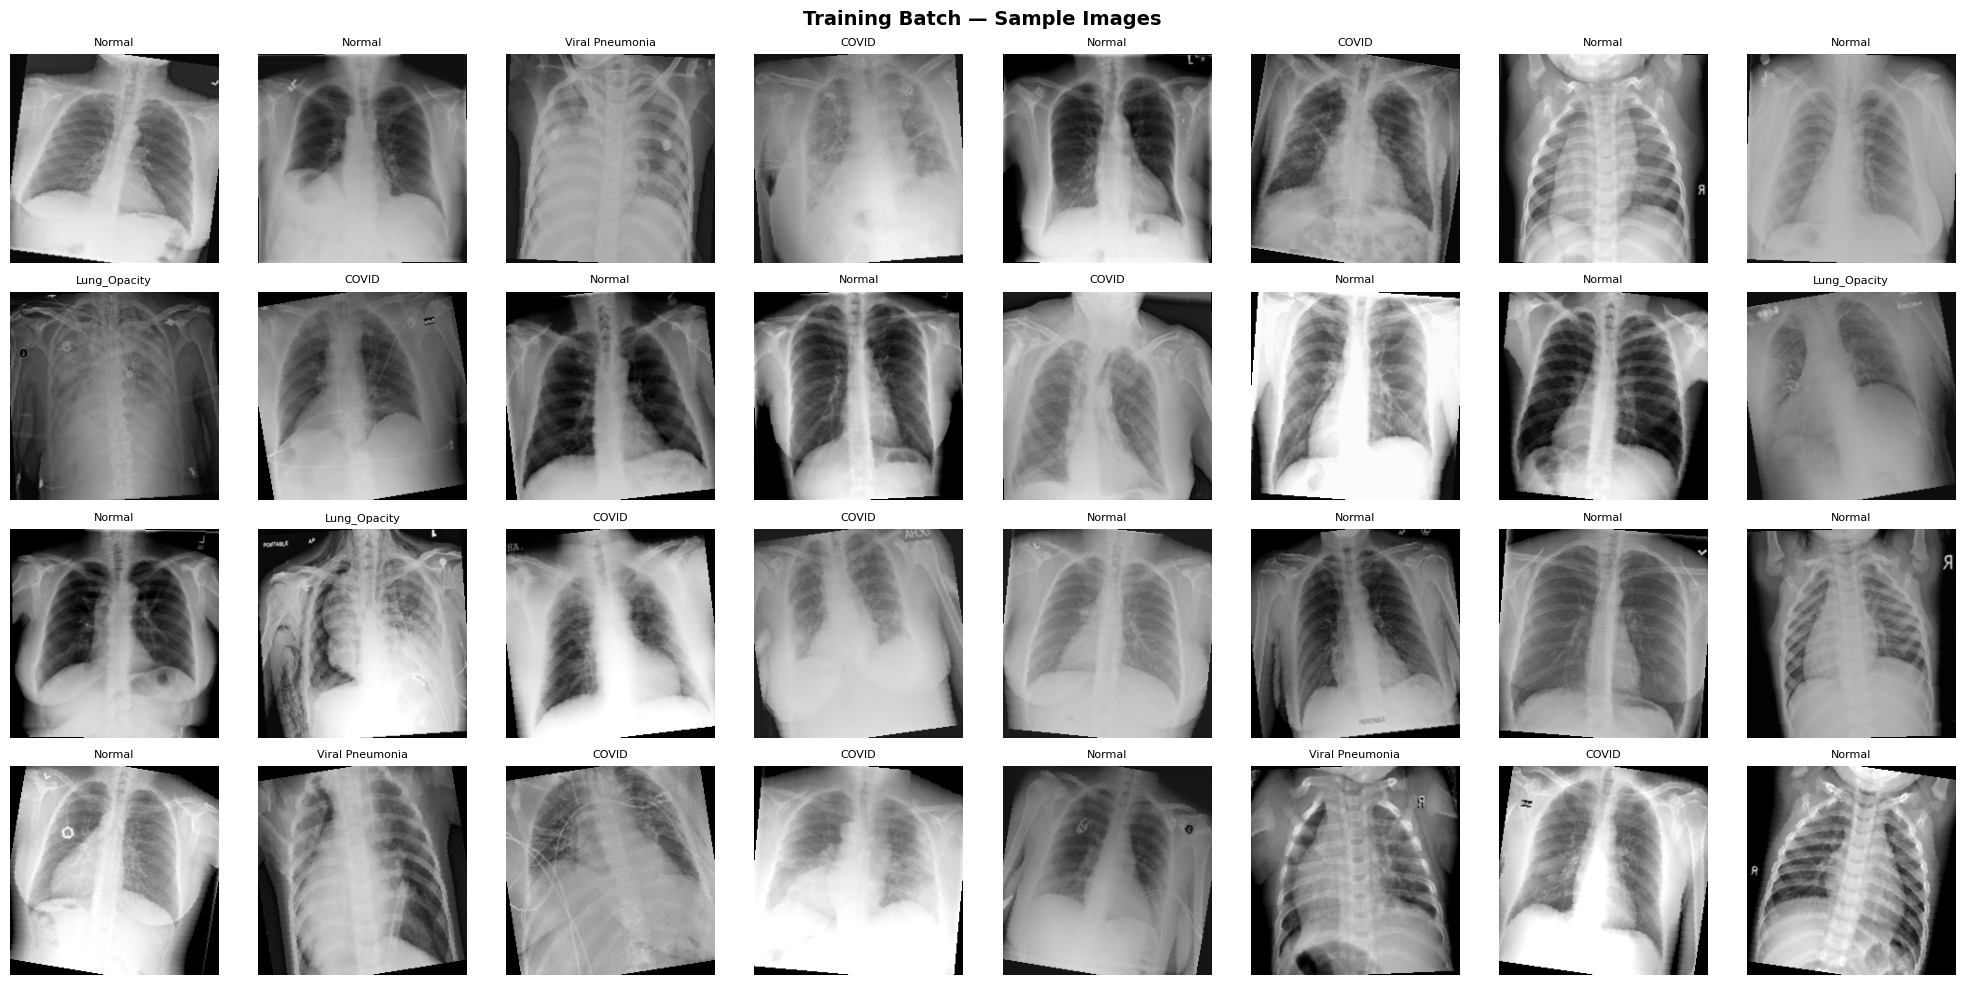

╔══════════════════════════════════════════════════════╗
║       🖼️   BATCH VISUALISATION COMPLETE              ║
╠══════════════════════════════════════════════════════╣
║  📦 Images shown : 32  (4 rows × 8 cols)            ║
║  📐 Image shape  : [3, 224, 224]              ║
║  🎨 Class labels shown above each image              ║
╠══════════════════════════════════════════════════════╣
║  💾 Saved → reports/batch_visualisation.png         ║
╚══════════════════════════════════════════════════════╝


In [4]:
# ============================================================
#   CELL 4 — VISUALISE A BATCH OF TRAINING IMAGES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Training Batch — Sample Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{REPORTS}/batch_visualisation.png", dpi=120, bbox_inches="tight")
plt.show()

print("╔══════════════════════════════════════════════════════╗")
print("║       🖼️   BATCH VISUALISATION COMPLETE              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📦 Images shown : 32  (4 rows × 8 cols)            ║")
print(f"║  📐 Image shape  : {list(images[0].shape)}              ║")
print("║  🎨 Class labels shown above each image              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/batch_visualisation.png         ║")
print("╚══════════════════════════════════════════════════════╝")

In [5]:
# ============================================================
#   CELL 5 — MODEL DEFINITIONS
#   ResNet50 | ResNet101 | DenseNet121
# ============================================================
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_resnet101(num_classes=NUM_CLASSES):
    model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_densenet121(num_classes=NUM_CLASSES):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

# ── Build all three ───────────────────────────────────────────
MODEL_REGISTRY = {
    "ResNet50"    : build_resnet50(),
    "ResNet101"   : build_resnet101(),
    "DenseNet121" : build_densenet121(),
}

# ── Output ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Total Params':>14} {'Trainable':>12} {'Frozen %':>10}  ║")
print("╠══════════════════════════════════════════════════════════════╣")

for name, model in MODEL_REGISTRY.items():
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_pct = 100 * (1 - trainable / total)
    print(f"║  {name:<14} {total:>14,} {trainable:>12,} {frozen_pct:>9.1f}%  ║")

print("╠══════════════════════════════════════════════════════════════╣")
print("║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║")
print("║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║")
print(f"║  ⚡ Device     : {str(DEVICE):<46}║")
print("╚══════════════════════════════════════════════════════════════╝")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.3MB/s]


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 141MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 134MB/s]


╔══════════════════════════════════════════════════════════════╗
║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Total Params    Trainable   Frozen %  ║
╠══════════════════════════════════════════════════════════════╣
║  ResNet50           24,033,604      525,572      97.8%  ║
║  ResNet101          43,025,732      525,572      98.8%  ║
║  DenseNet121         7,217,284      263,428      96.4%  ║
╠══════════════════════════════════════════════════════════════╣
║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║
║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║
║  ⚡ Device     : cpu                                           ║
╚══════════════════════════════════════════════════════════════╝


In [6]:
# ============================================================
#   CELL 6 — TRAINING & EVALUATION FUNCTIONS (WITH FINE-TUNE)
# ============================================================
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import time, copy

# ── Hyperparameters ───────────────────────────────────────────
EPOCHS_HEAD   = 5       # Stage 1 — head only
EPOCHS_FINETUNE = 5     # Stage 2 — full model
LR_HEAD       = 1e-3    # higher LR for new head
LR_FINETUNE   = 1e-5    # very low LR for pretrained backbone
STEP_SIZE     = 3
GAMMA         = 0.5


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
    return running_loss / total, correct / total


def run_stage(name, stage, model, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_acc  = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    start     = time.time()

    print("╔══════════════════════════════════════════════════════════════════╗")
    print(f"║  {stage}  :  {name:<52}║")
    print(f"║  📋 Epochs : {epochs}   📐 LR : {lr:<42}║")
    print("╠════════╦══════════════╦══════════════╦══════════╦══════════╦═════╣")
    print("║ Epoch  ║  Train Loss  ║   Val Loss   ║ Train Acc║  Val Acc ║     ║")
    print("╠════════╬══════════════╬══════════════╬══════════╬══════════╬═════╣")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = "⭐" if v_acc > best_acc else "  "
        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"║  {epoch:>3}/{epochs}  ║  {t_loss:>8.4f}    ║  {v_loss:>8.4f}    ║"
              f"  {t_acc*100:>5.2f}%  ║  {v_acc*100:>5.2f}%  ║ {flag} ║")

    elapsed = time.time() - start
    model.load_state_dict(best_wts)
    print("╠════════╩══════════════╩══════════════╩══════════╩══════════╩═════╣")
    print(f"║  ✅ Best Val Acc : {best_acc*100:.2f}%   ⏱️  Time : {elapsed:.1f}s{' '*25}║")
    print("╚══════════════════════════════════════════════════════════════════╝\n")

    return model, history, best_acc


def train_model(name, model):
    all_history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    # ── Stage 1: Train head only ──────────────────────────────
    model, h1, acc1 = run_stage(
        name, "🧊 STAGE 1 — HEAD ONLY (Backbone Frozen)",
        model, EPOCHS_HEAD, LR_HEAD
    )
    for k in all_history: all_history[k] += h1[k]

    # ── Stage 2: Unfreeze & fine-tune ─────────────────────────
    for param in model.parameters():
        param.requires_grad = True

    model, h2, acc2 = run_stage(
        name, "🔥 STAGE 2 — FINE-TUNE (Full Model Unfrozen)",
        model, EPOCHS_FINETUNE, LR_FINETUNE
    )
    for k in all_history: all_history[k] += h2[k]

    best_final = max(acc1, acc2)
    return model, all_history, best_final


print("╔══════════════════════════════════════════════════════╗")
print("║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🧊 Stage 1 — Head Only                             ║")
print(f"║     Epochs : {EPOCHS_HEAD}   LR : {LR_HEAD:<31}║")
print(f"║  🔥 Stage 2 — Full Fine-Tune                        ║")
print(f"║     Epochs : {EPOCHS_FINETUNE}   LR : {LR_FINETUNE:<31}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📉 Loss      : CrossEntropyLoss                    ║")
print(f"║  ⚙️  Optimizer : Adam                                ║")
print(f"║  📉 Scheduler : StepLR (step={STEP_SIZE}, γ={GAMMA})            ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Functions : train_one_epoch() │ evaluate()          ║")
print("║            : run_stage()       │ train_model()       ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║
╠══════════════════════════════════════════════════════╣
║  🧊 Stage 1 — Head Only                             ║
║     Epochs : 5   LR : 0.001                          ║
║  🔥 Stage 2 — Full Fine-Tune                        ║
║     Epochs : 5   LR : 1e-05                          ║
╠══════════════════════════════════════════════════════╣
║  📉 Loss      : CrossEntropyLoss                    ║
║  ⚙️  Optimizer : Adam                                ║
║  📉 Scheduler : StepLR (step=3, γ=0.5)            ║
╠══════════════════════════════════════════════════════╣
║  Functions : train_one_epoch() │ evaluate()          ║
║            : run_stage()       │ train_model()       ║
╚══════════════════════════════════════════════════════╝


In [ ]:
# ============================================================
#   CELL 7 — TRAIN OR LOAD ALL THREE MODELS
# ============================================================
import copy, os

ALL_HISTORIES  = {}
BEST_MODELS    = {}
TRAINED_MODELS = {}

FORCE_RETRAIN = False   # ← Set True ONLY if you want to retrain

for model_name, model in MODEL_REGISTRY.items():

    # Check if checkpoint already exists on Drive
    ckpt_files = [f for f in os.listdir(WEIGHTS)
                  if model_name in f and "checkpoint" in f]

    if ckpt_files and not FORCE_RETRAIN:
        # ── LOAD from Drive ───────────────────────────────────
        ckpt_path = os.path.join(WEIGHTS, sorted(ckpt_files)[-1])
        ckpt      = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["state_dict"])
        model.eval()

        # Dummy history for plotting
        dummy_hist = {
            "train_loss": ckpt.get("train_loss", []),
            "val_loss"  : ckpt.get("val_loss",   []),
            "train_acc" : ckpt.get("train_acc",  []),
            "val_acc"   : ckpt.get("val_acc_hist", []),
        }
        best_acc = ckpt.get("val_acc", 0.0)

        ALL_HISTORIES[model_name]  = dummy_hist
        BEST_MODELS[model_name]    = copy.deepcopy(model.state_dict())
        TRAINED_MODELS[model_name] = (model, dummy_hist, best_acc)

        print(f"✅ {model_name} loaded from checkpoint — skipping training")

    else:
        # ── TRAIN from scratch ────────────────────────────────
        print(f"\n🏋️  Training {model_name} from scratch...")

        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():         param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters(): param.requires_grad = True

        model, h1, _ = run_stage(
            name=model_name, stage="🧊 STAGE 1 — HEAD ONLY",
            model=model, epochs=EPOCHS_HEAD, lr=LR_HEAD
        )

        for param in model.parameters():
            param.requires_grad = True

        model, h2, best_acc = run_stage(
            name=model_name, stage="🔥 STAGE 2 — FINE-TUNE",
            model=model, epochs=EPOCHS_FINETUNE, lr=LR_FINETUNE
        )

        merged_hist = {k: h1[k] + h2[k] for k in h1}
        ALL_HISTORIES[model_name]  = merged_hist
        BEST_MODELS[model_name]    = copy.deepcopy(model.state_dict())
        TRAINED_MODELS[model_name] = (model, merged_hist, best_acc)

        # ── Save checkpoint with history ──────────────────────
        import datetime
        ts        = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        ckpt_path = f"{WEIGHTS}/{model_name}_checkpoint_{ts}.pth"
        torch.save({
            "state_dict"  : model.state_dict(),
            "val_acc"     : best_acc,
            "train_loss"  : merged_hist["train_loss"],
            "val_loss"    : merged_hist["val_loss"],
            "train_acc"   : merged_hist["train_acc"],
            "val_acc_hist": merged_hist["val_acc"],
            "class_names" : CLASS_NAMES,
            "num_classes" : NUM_CLASSES,
        }, ckpt_path)
        print(f"💾 Saved → {ckpt_path.split('/')[-1]}")

# ── Summary ───────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║      ✅  ALL MODELS READY                            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Source':<12} {'Best Val Acc':>14}  ║")
print("╠══════════════════════════════════════════════════════╣")
for name, (_, _, best) in TRAINED_MODELS.items():
    source = "💾 Loaded" if not FORCE_RETRAIN and any(
        name in f for f in os.listdir(WEIGHTS)) else "🏋️  Trained"
    print(f"║  {name:<14} {source:<12} {best*100:>12.2f}%   ║")
print("╚══════════════════════════════════════════════════════╝")


🏋️  Training ResNet50 from scratch...
╔══════════════════════════════════════════════════════════════════╗
║  🧊 STAGE 1 — HEAD ONLY  :  ResNet50                                            ║
║  📋 Epochs : 5   📐 LR : 0.001                                     ║
╠════════╦══════════════╦══════════════╦══════════╦══════════╦═════╣
║ Epoch  ║  Train Loss  ║   Val Loss   ║ Train Acc║  Val Acc ║     ║
╠════════╬══════════════╬══════════════╬══════════╬══════════╬═════╣


In [ ]:
# ============================================================
#   CELL 8 — FINAL ACCURACY SUMMARY
# ============================================================
import pandas as pd

criterion = nn.CrossEntropyLoss()
summary   = []
TRAINED_MODELS_EVAL = {}

for name, (model, history, best_val_acc) in TRAINED_MODELS.items():
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    val_loss,  val_acc  = evaluate(model, val_loader,  criterion)
    summary.append({
        "Model"        : name,
        "Val Acc"      : val_acc   * 100,
        "Test Acc"     : test_acc  * 100,
        "Test Loss"    : test_loss,
        "Best Val Acc" : best_val_acc * 100,
    })
    TRAINED_MODELS_EVAL[name] = model

df_summary = pd.DataFrame(summary).sort_values(
    "Test Acc", ascending=False).reset_index(drop=True)
df_summary.to_csv(f"{REPORTS}/accuracy_summary.csv", index=False)

best_row        = df_summary.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
BEST_MODEL      = TRAINED_MODELS_EVAL[BEST_MODEL_NAME]

# ── Pre-compute strings (avoids f-string backslash issue) ─────
test_acc_str = f"{best_row['Test Acc']:.2f}%"
val_acc_str  = f"{best_row['Val Acc']:.2f}%"
loss_str     = f"{best_row['Test Loss']:.4f}"
medals       = ["🥇", "🥈", "🥉"]

print("╔══════════════════════════════════════════════════════════════════╗")
print("║                 📊  FINAL ACCURACY SUMMARY                      ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Rank':<6} {'Model':<14} {'Val Acc':>10} {'Test Acc':>10} {'Test Loss':>12}  ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for i, row in df_summary.iterrows():
    medal    = medals[i] if i < 3 else "  "
    bar_len  = int((row["Test Acc"] - 80) / 20 * 10)
    bar      = "█" * bar_len + "░" * (10 - bar_len)
    print(f"║  {medal} {i+1:<3}  {row['Model']:<14}"
          f"{row['Val Acc']:>8.2f}%  "
          f"{row['Test Acc']:>8.2f}%  "
          f"{row['Test Loss']:>10.4f}   ║")
    print(f"║           {bar:<54}  ║")

print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model  : {BEST_MODEL_NAME:<47}║")
print(f"║  ✅ Test Acc    : {test_acc_str}{' '*(46 - len(test_acc_str))}║")
print(f"║  ✅ Val Acc     : {val_acc_str}{' '*(46 - len(val_acc_str))}║")
print(f"║  📉 Test Loss   : {loss_str}{' '*(46 - len(loss_str))}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved  → reports/accuracy_summary.csv                      ║")
print(f"║  📌 BEST_MODEL & BEST_MODEL_NAME set for next cells            ║")
print("╚══════════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 9 — TRAINING CURVES
# ============================================================
# ── Guard: skip if history is empty (loaded from checkpoint) ──
has_history = any(
    len(hist["train_loss"]) > 0
    for hist in ALL_HISTORIES.values()
)

if not has_history:
    print("╔══════════════════════════════════════════════════════╗")
    print("║  ⚠️  No training history found                       ║")
    print("║  Models were loaded from checkpoints                 ║")
    print("║  Re-train with FORCE_RETRAIN=True to get curves      ║")
    print("╚══════════════════════════════════════════════════════╝")
else:
# ... rest of Cell 9 plotting code
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Training Curves — Loss & Accuracy (Stage 1 + Stage 2)",
             fontsize=14, fontweight="bold", y=1.01)

colors = {"train": "#3498db", "val": "#e74c3c"}

for i, (name, hist) in enumerate(ALL_HISTORIES.items()):
    epochs      = range(1, len(hist["train_loss"]) + 1)
    stage_split = EPOCHS_HEAD

    # ── Loss ──────────────────────────────────────────────────
    ax_loss = axes[i][0]
    ax_loss.plot(epochs, hist["train_loss"], color=colors["train"],
                 linewidth=2, marker="o", markersize=3, label="Train Loss")
    ax_loss.plot(epochs, hist["val_loss"],   color=colors["val"],
                 linewidth=2, marker="o", markersize=3, label="Val Loss")
    ax_loss.axvline(x=stage_split + 0.5, color="gray",
                    linestyle="--", linewidth=1.5, label="Fine-tune starts")
    ax_loss.fill_between(epochs, hist["train_loss"], hist["val_loss"],
                         alpha=0.07, color="#9b59b6")
    ax_loss.set_title(f"{name} — Loss", fontweight="bold")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=9)
    ax_loss.grid(linestyle="--", alpha=0.4)
    ax_loss.spines[["top","right"]].set_visible(False)
    ax_loss.annotate("🔥 Fine-tune",
                     xy=(stage_split + 0.6, max(hist["val_loss"]) * 0.95),
                     fontsize=8, color="gray")

    # ── Accuracy ──────────────────────────────────────────────
    ax_acc = axes[i][1]
    t_accs = [a * 100 for a in hist["train_acc"]]
    v_accs = [a * 100 for a in hist["val_acc"]]
    ax_acc.plot(epochs, t_accs, color=colors["train"],
                linewidth=2, marker="o", markersize=3, label="Train Acc")
    ax_acc.plot(epochs, v_accs, color=colors["val"],
                linewidth=2, marker="o", markersize=3, label="Val Acc")
    ax_acc.axvline(x=stage_split + 0.5, color="gray",
                   linestyle="--", linewidth=1.5)
    ax_acc.fill_between(epochs, t_accs, v_accs, alpha=0.07, color="#9b59b6")

    # Mark best val acc point
    best_epoch = v_accs.index(max(v_accs)) + 1
    ax_acc.annotate(f"⭐ {max(v_accs):.1f}%",
                    xy=(best_epoch, max(v_accs)),
                    xytext=(best_epoch + 0.4, max(v_accs) - 2),
                    fontsize=8, color="#e74c3c",
                    arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1))

    ax_acc.set_title(f"{name} — Accuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_ylim(50, 100)
    ax_acc.legend(fontsize=9)
    ax_acc.grid(linestyle="--", alpha=0.4)
    ax_acc.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{REPORTS}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║         📈  TRAINING CURVES COMPLETE                 ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Best Train':>11} {'Best Val':>10} {'@ Epoch':>8}  ║")
print("╠══════════════════════════════════════════════════════╣")
for name, hist in ALL_HISTORIES.items():
    best_t   = max(hist["train_acc"]) * 100
    best_v   = max(hist["val_acc"])   * 100
    best_ep  = hist["val_acc"].index(max(hist["val_acc"])) + 1
    print(f"║  {name:<14} {best_t:>9.2f}%  {best_v:>8.2f}%  {best_ep:>7}   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📉 Dashed line : Fine-tune stage begins            ║")
print(f"║  🔵 Blue        : Training                          ║")
print(f"║  🔴 Red         : Validation                        ║")
print(f"║  ⭐ Star        : Best Val Accuracy point           ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/training_curves.png             ║")
print("╚══════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 10 — CONFUSION MATRICES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(ax, cm, title):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual",    fontsize=9)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i,j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm[i,j] > thresh else "black")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models (Test Set)",
             fontsize=14, fontweight="bold")

cms = {}
for i, (name, (model, _, _)) in enumerate(TRAINED_MODELS.items()):
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    cms[name] = (cm, y_true, y_pred)   # store y_true/y_pred for Cell 11
    plot_confusion_matrix(axes[i], cm, name)

plt.tight_layout()
plt.savefig(f"{REPORTS}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║           🔲  CONFUSION MATRICES COMPLETE                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<16} {'Correct':>8} {'Total':>7} {'Acc':>8}          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for name, (cm, _, _) in cms.items():
    correct = np.trace(cm)
    total   = cm.sum()
    acc     = correct / total * 100
    bar_len = int(acc / 100 * 15)
    bar     = "█" * bar_len + "░" * (15 - bar_len)
    print(f"║  🧠 {name:<14} {correct:>7}  {total:>6}  {acc:>6.2f}%  {bar} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📌 Rows  = Actual Class                                     ║")
print("║  📌 Cols  = Predicted Class                                  ║")
print("║  📌 Diag  = Correct Predictions                              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📦 cms dict stored → used in Cell 11                       ║")
print(f"║  💾 Saved → reports/confusion_matrices.png                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 11 — PER-CLASS CLASSIFICATION REPORTS
# ============================================================
import pandas as pd
from sklearn.metrics import classification_report

all_reports = {}

for name, (cm, y_true, y_pred) in cms.items():
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    all_reports[name] = report

    # ── Per model box ─────────────────────────────────────────
    print("╔══════════════════════════════════════════════════════════════════════╗")
    print(f"║  🧠 CLASSIFICATION REPORT — {name:<43}║")
    print("╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣")
    print("║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║")
    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")

    for cls in CLASS_NAMES:
        p  = report[cls]["precision"] * 100
        r  = report[cls]["recall"]    * 100
        f1 = report[cls]["f1-score"]  * 100
        s  = int(report[cls]["support"])
        print(f"║  {cls:<12}  ║  {p:>7.2f}%   ║  {r:>6.2f}%  ║   {f1:>7.2f}%    ║  {s:>8}  ║")

    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
    ma_p  = report["macro avg"]["precision"]  * 100
    ma_r  = report["macro avg"]["recall"]     * 100
    ma_f1 = report["macro avg"]["f1-score"]   * 100
    wa_f1 = report["weighted avg"]["f1-score"]* 100
    acc   = report["accuracy"]                * 100

    print(f"║  {'Macro Avg':<12}  ║  {ma_p:>7.2f}%   ║  {ma_r:>6.2f}%  ║   {ma_f1:>7.2f}%    ║            ║")
    print(f"║  {'Weighted Avg':<12}  ║             ║            ║   {wa_f1:>7.2f}%    ║            ║")
    print("╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣")
    print(f"║  ✅ Overall Accuracy : {acc:.2f}%{' ' * (47 - len(f'{acc:.2f}%'))}║")
    print("╚══════════════════════════════════════════════════════════════════════╝\n")

# ── Save all reports to CSV ───────────────────────────────────
rows = []
for name, report in all_reports.items():
    for cls in CLASS_NAMES:
        rows.append({
            "Model"    : name,
            "Class"    : cls,
            "Precision": round(report[cls]["precision"], 4),
            "Recall"   : round(report[cls]["recall"],    4),
            "F1-Score" : round(report[cls]["f1-score"],  4),
            "Support"  : int(report[cls]["support"]),
        })

df_reports = pd.DataFrame(rows)
df_reports.to_csv(f"{REPORTS}/classification_reports.csv", index=False)

print("╔══════════════════════════════════════════════════════╗")
print("║     ✅  ALL CLASSIFICATION REPORTS COMPLETE          ║")
print("╠══════════════════════════════════════════════════════╣")
for name, report in all_reports.items():
    acc = report["accuracy"] * 100
    f1  = report["macro avg"]["f1-score"] * 100
    print(f"║  🧠 {name:<14}  Acc: {acc:.2f}%   F1: {f1:.2f}%   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/classification_reports.csv      ║")
print("╚══════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 12 — MODEL COMPARISON BAR CHART
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

models      = df_summary["Model"].tolist()
val_accs    = df_summary["Val Acc"].tolist()
test_accs   = df_summary["Test Acc"].tolist()
test_losses = df_summary["Test Loss"].tolist()

# F1 scores from classification reports
f1_scores = [all_reports[m]["macro avg"]["f1-score"] * 100 for m in models]

x     = np.arange(len(models))
width = 0.25
colors = ["#3498db", "#2ecc71", "#e74c3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — ResNet50 vs ResNet101 vs DenseNet121",
             fontsize=14, fontweight="bold")

# ── Left: Val Acc / Test Acc / F1 grouped bars ───────────────
bars1 = ax1.bar(x - width,   val_accs,   width, label="Val Acc",
                color=colors[0], alpha=0.85, edgecolor="white")
bars2 = ax1.bar(x,           test_accs,  width, label="Test Acc",
                color=colors[1], alpha=0.85, edgecolor="white")
bars3 = ax1.bar(x + width,   f1_scores,  width, label="Macro F1",
                color=colors[2], alpha=0.85, edgecolor="white")

ax1.set_title("Accuracy & F1 Score", fontweight="bold")
ax1.set_ylabel("Score (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(80, 100)
ax1.legend(fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top","right"]].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=8)

# Best model annotation
best_idx = test_accs.index(max(test_accs))
ax1.annotate("🏆",
             xy=(best_idx, max(test_accs) + 0.8),
             ha="center", fontsize=14)

# ── Right: Test Loss ──────────────────────────────────────────
bar_colors = ["#e74c3c" if m == BEST_MODEL_NAME else "#95a5a6" for m in models]
bars4 = ax2.bar(models, test_losses, color=bar_colors,
                alpha=0.85, edgecolor="white", width=0.4)

ax2.set_title("Test Loss per Model", fontweight="bold")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.set_ylim(0, max(test_losses) * 1.3)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top","right"]].set_visible(False)

for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(f"{REPORTS}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         📊  MODEL COMPARISON CHART COMPLETE                  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Val Acc':>9} {'Test Acc':>10} {'F1':>8} {'Loss':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
medals = ["🥇","🥈","🥉"]
for i, row in df_summary.iterrows():
    f1 = all_reports[row["Model"]]["macro avg"]["f1-score"] * 100
    print(f"║  {medals[i]} {row['Model']:<13}"
          f"{row['Val Acc']:>8.2f}% "
          f"{row['Test Acc']:>8.2f}% "
          f"{f1:>7.2f}% "
          f"{row['Test Loss']:>7.4f}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model : {BEST_MODEL_NAME:<45}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/model_comparison.png                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 13 — VERIFY SAVED WEIGHTS
# ============================================================
import os

files = [f for f in os.listdir(WEIGHTS)]

print("╔══════════════════════════════════════════════════════╗")
print("║         💾  SAVED WEIGHTS — VERIFICATION             ║")
print("╠══════════════════════════════════════════════════════╣")
for f in sorted(files):
    size = os.path.getsize(os.path.join(WEIGHTS, f)) / (1024 * 1024)
    print(f"║  📄 {f:<38} {size:>5.1f} MB  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📁 Path : {WEIGHTS[-50:]:<51}║")
print("╚══════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 14 — SINGLE IMAGE INFERENCE DEMO
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch, os, random
import torch.nn.functional as F

# ── Inference transform (no augmentation) ────────────────────
infer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(img_path, model):
    model.eval()
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probs  = F.softmax(output, dim=1).squeeze().cpu().numpy()
    pred_idx   = probs.argmax()
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    return img, pred_label, confidence, probs

# ── Pick one random image per class ──────────────────────────
CLASS_COLORS = {
    "COVID"           : "#e74c3c",
    "Lung_Opacity"    : "#f39c12",
    "Normal"          : "#2ecc71",
    "Viral Pneumonia" : "#3498db"
}

sample_images = []
for cls in CLASS_NAMES:
    img_dir = os.path.join(DATA_PATH, cls, "images")
    if not os.path.exists(img_dir):
        img_dir = os.path.join(DATA_PATH, cls)
    fname = random.choice(os.listdir(img_dir))
    sample_images.append((os.path.join(img_dir, fname), cls))

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"Inference Demo — {BEST_MODEL_NAME}",
             fontsize=14, fontweight="bold")

results = []
for i, (img_path, true_label) in enumerate(sample_images):
    img, pred_label, confidence, probs = predict_image(img_path, BEST_MODEL)

    correct = pred_label == true_label
    color   = "#2ecc71" if correct else "#e74c3c"

    # ── Image ─────────────────────────────────────────────────
    ax_img = axes[0][i]
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title(
        f"True : {true_label}\nPred : {pred_label}  ({confidence:.1f}%)",
        fontsize=9, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85)
    )
    ax_img.axis("off")

    # ── Probability bar ───────────────────────────────────────
    ax_bar = axes[1][i]
    bar_colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
    bars = ax_bar.barh(CLASS_NAMES, probs * 100,
                       color=bar_colors, alpha=0.8, edgecolor="white")
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", fontsize=8)
    ax_bar.axvline(x=50, color="gray", linestyle="--", linewidth=0.8)
    ax_bar.spines[["top","right"]].set_visible(False)
    ax_bar.tick_params(labelsize=8)
    for bar, prob in zip(bars, probs):
        ax_bar.text(min(prob*100 + 1, 95), bar.get_y() + bar.get_height()/2,
                    f"{prob*100:.1f}%", va="center", fontsize=7)

    results.append({
        "true": true_label, "pred": pred_label,
        "conf": confidence, "correct": correct
    })

plt.tight_layout()
plt.savefig(f"{REPORTS}/inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print(f"║        🔍  INFERENCE DEMO — {BEST_MODEL_NAME:<34}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'True Label':<18} {'Predicted':<18} {'Conf':>8} {'Result':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
for r in results:
    status = "✅ Correct" if r["correct"] else "❌ Wrong"
    print(f"║  {r['true']:<18} {r['pred']:<18} {r['conf']:>6.1f}%  {status:<10}║")
print("╠══════════════════════════════════════════════════════════════╣")
correct_count = sum(r["correct"] for r in results)
print(f"║  ✅ Correct : {correct_count}/{len(results)}{' '*48}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/inference_demo.png                      ║")
print("╚══════════════════════════════════════════════════════════════╝")

# Phase 3

In [ ]:
# ============================================================
#   CELL 15 — ENSEMBLE (WEIGHTED SOFTMAX AVERAGING)
# ============================================================
import torch
import torch.nn.functional as F

# ── Ensemble weights ──────────────────────────────────────────
ENSEMBLE_WEIGHTS = {
    "ResNet50"    : 0.30,
    "ResNet101"   : 0.30,
    "DenseNet121" : 0.40,
}

def ensemble_predict(loaders, trained_models, weights):
    all_probs  = {name: [] for name in trained_models}
    all_labels = []
    collected  = False

    for name, (model, _, _) in trained_models.items():
        model.eval()
        with torch.no_grad():
            for images, labels in loaders:
                images = images.to(DEVICE)
                logits = model(images)
                probs  = F.softmax(logits, dim=1).cpu()
                all_probs[name].append(probs)
                if not collected:
                    all_labels.append(labels)
        collected = True

    # Stack per model
    for name in all_probs:
        all_probs[name] = torch.cat(all_probs[name], dim=0)

    labels_all = torch.cat(all_labels, dim=0)

    # Weighted average
    ensemble_probs = sum(
        all_probs[name] * weights[name]
        for name in all_probs
    )

    preds = ensemble_probs.argmax(dim=1)
    acc   = (preds == labels_all).float().mean().item()
    return ensemble_probs, preds.numpy(), labels_all.numpy(), acc


print("╔══════════════════════════════════════════════════════════════╗")
print("║         🤝  ENSEMBLE SETUP READY                             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Strategy : Weighted Softmax Averaging                       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Weight':>8} {'Contribution':>14}          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for name, w in ENSEMBLE_WEIGHTS.items():
    bar = "█" * int(w * 20)
    print(f"║  {name:<14} {w:>7.0%}   {bar:<20}              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Formula:                                                    ║")
print("║  P_final = 0.30×P(R50) + 0.30×P(R101) + 0.40×P(DN121)      ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  ✅ ensemble_predict() ready                                 ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 16 — ENSEMBLE EVALUATION + COMPARISON
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# ── Run ensemble on test set ──────────────────────────────────
print("⏳ Running ensemble on test set...")
ens_probs, ens_preds, ens_labels, ens_acc = ensemble_predict(
    test_loader, TRAINED_MODELS, ENSEMBLE_WEIGHTS
)
print("✅ Done!\n")

# ── Run ensemble on val set ───────────────────────────────────
print("⏳ Running ensemble on val set...")
_, _, ens_val_labels, ens_val_acc = ensemble_predict(
    val_loader, TRAINED_MODELS, ENSEMBLE_WEIGHTS
)
print("✅ Done!\n")

# ── F1 scores ─────────────────────────────────────────────────
ens_report  = classification_report(
    ens_labels, ens_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)
ens_f1      = ens_report["macro avg"]["f1-score"] * 100
ens_test_acc = ens_acc * 100
ens_val_acc  = ens_val_acc * 100

# ── Build comparison table ────────────────────────────────────
rows = []
for name, row in zip(df_summary["Model"], df_summary.itertuples()):
    f1 = all_reports[name]["macro avg"]["f1-score"] * 100
    rows.append({
        "Model"    : name,
        "Val Acc"  : row._2,
        "Test Acc" : row._3,
        "Macro F1" : f1,
    })

# Add ensemble row
rows.append({
    "Model"    : "🤝 Ensemble",
    "Val Acc"  : ens_val_acc,
    "Test Acc" : ens_test_acc,
    "Macro F1" : ens_f1,
})

df_compare = pd.DataFrame(rows).sort_values("Test Acc", ascending=False).reset_index(drop=True)
df_compare.to_csv(f"{REPORTS}/ensemble_comparison.csv", index=False)

# ── Output ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════╗")
print("║         🤝  ENSEMBLE vs INDIVIDUAL — COMPARISON                 ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<16} {'Val Acc':>10} {'Test Acc':>10} {'Macro F1':>10}      ║")
print("╠══════════════════════════════════════════════════════════════════╣")

medals = ["🥇","🥈","🥉","4️⃣ "]
for i, row in df_compare.iterrows():
    medal  = medals[i] if i < 4 else "   "
    is_ens = "←★" if row["Model"] == "🤝 Ensemble" else "  "
    print(f"║  {medal} {row['Model']:<15}"
          f"{row['Val Acc']:>8.2f}%  "
          f"{row['Test Acc']:>8.2f}%  "
          f"{row['Macro F1']:>8.2f}%  {is_ens}  ║")

print("╠══════════════════════════════════════════════════════════════════╣")

# Gain over best individual
best_individual = df_summary.iloc[0]["Test Acc"]
gain            = ens_test_acc - best_individual
gain_str        = f"+{gain:.2f}%" if gain >= 0 else f"{gain:.2f}%"
verdict         = "✅ Ensemble WINS" if gain >= 0 else "⚠️  Best individual wins"

print(f"║  📈 Gain over best individual : {gain_str:<34}║")
print(f"║  {verdict:<65}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/ensemble_comparison.csv                    ║")
print("╚══════════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 17 — ENSEMBLE CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import itertools, pandas as pd

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(ens_labels, ens_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble — Confusion Matrix & Per-Class Metrics",
             fontsize=14, fontweight="bold")

# ── Left: Confusion Matrix ────────────────────────────────────
ax = axes[0]
ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual",    fontsize=10)
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, f"{cm[i,j]}",
            ha="center", va="center", fontsize=10,
            color="white" if cm[i,j] > thresh else "black")

# ── Right: Per-Class Bar Chart ────────────────────────────────
ax2     = axes[1]
report  = classification_report(
    ens_labels, ens_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

metrics     = ["precision", "recall", "f1-score"]
x           = np.arange(len(CLASS_NAMES))
width       = 0.25
bar_colors  = ["#3498db", "#2ecc71", "#e74c3c"]

for i, metric in enumerate(metrics):
    vals = [report[cls][metric] * 100 for cls in CLASS_NAMES]
    bars = ax2.bar(x + i * width, vals, width,
                   label=metric.capitalize(),
                   color=bar_colors[i], alpha=0.85, edgecolor="white")
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}",
                 ha="center", va="bottom", fontsize=7)

ax2.set_title("Per-Class Precision / Recall / F1", fontweight="bold")
ax2.set_ylabel("Score (%)")
ax2.set_xticks(x + width)
ax2.set_xticklabels(CLASS_NAMES, fontsize=9)
ax2.set_ylim(70, 105)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{REPORTS}/ensemble_confusion_report.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save CSV ──────────────────────────────────────────────────
rows = []
for cls in CLASS_NAMES:
    rows.append({
        "Class"    : cls,
        "Precision": round(report[cls]["precision"], 4),
        "Recall"   : round(report[cls]["recall"],    4),
        "F1-Score" : round(report[cls]["f1-score"],  4),
        "Support"  : int(report[cls]["support"]),
    })
df_ens_report = pd.DataFrame(rows)
df_ens_report.to_csv(f"{REPORTS}/ensemble_classification_report.csv", index=False)

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║       🤝  ENSEMBLE — CLASSIFICATION REPORT                          ║")
print("╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣")
print("║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║")
print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
for cls in CLASS_NAMES:
    p  = report[cls]["precision"] * 100
    r  = report[cls]["recall"]    * 100
    f1 = report[cls]["f1-score"]  * 100
    s  = int(report[cls]["support"])
    print(f"║  {cls:<12}  ║  {p:>7.2f}%   ║  {r:>6.2f}%  ║   {f1:>7.2f}%    ║  {s:>8}  ║")
print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
ma_p  = report["macro avg"]["precision"]   * 100
ma_r  = report["macro avg"]["recall"]      * 100
ma_f1 = report["macro avg"]["f1-score"]    * 100
acc   = report["accuracy"]                 * 100
print(f"║  {'Macro Avg':<12}  ║  {ma_p:>7.2f}%   ║  {ma_r:>6.2f}%  ║   {ma_f1:>7.2f}%    ║            ║")
print("╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣")
print(f"║  ✅ Ensemble Accuracy : {acc:.2f}%{' '*(46 - len(f'{acc:.2f}%'))}║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/ensemble_confusion_report.png                  ║")
print(f"║  💾 Saved → reports/ensemble_classification_report.csv            ║")
print("╚══════════════════════════════════════════════════════════════════════╝")

In [ ]:
# ============================================================
#   CELL 18 — SAVE ENSEMBLE CONFIG
# ============================================================
import json, os
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Save ensemble config ──────────────────────────────────────
ensemble_config = {
    "timestamp"        : timestamp,
    "strategy"         : "weighted_softmax_average",
    "weights"          : ENSEMBLE_WEIGHTS,
    "class_names"      : CLASS_NAMES,
    "num_classes"      : NUM_CLASSES,
    "img_size"         : IMG_SIZE,
    "normalize"        : {
        "mean" : [0.485, 0.456, 0.406],
        "std"  : [0.229, 0.224, 0.225]
    },
    "models"           : {},
    "ensemble_metrics" : {
        "test_acc"  : round(ens_test_acc, 4),
        "val_acc"   : round(ens_val_acc,  4),
        "macro_f1"  : round(ens_f1,       4),
    }
}

# Add per-model checkpoint references
for name in TRAINED_MODELS:
    ckpt_files = sorted([
        f for f in os.listdir(WEIGHTS)
        if name in f and "checkpoint" in f
    ])
    ensemble_config["models"][name] = {
        "checkpoint"   : ckpt_files[-1] if ckpt_files else "not found",
        "weight"       : ENSEMBLE_WEIGHTS[name],
        "test_acc"     : round(float(
            df_summary[df_summary["Model"] == name]["Test Acc"].values[0]
        ), 4),
    }

config_path = f"{WEIGHTS}/ensemble_config.json"
with open(config_path, "w") as f:
    json.dump(ensemble_config, f, indent=4)

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         💾  ENSEMBLE CONFIG SAVED                            ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📅 Timestamp   : {timestamp:<44}║")
print(f"║  ⚙️  Strategy    : Weighted Softmax Average{' '*21}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  🧠 Models & Weights :                                       ║")
for name, info in ensemble_config["models"].items():
    print(f"║     {name:<14} → weight: {info['weight']}  "
          f"test_acc: {info['test_acc']:.2f}%{' '*10}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📊 Ensemble Metrics :                                       ║")
print(f"║     ✅ Test Acc  : {ens_test_acc:.2f}%{' '*43}║"[:66]+"║")
print(f"║     ✅ Val Acc   : {ens_val_acc:.2f}%{' '*43}║"[:66]+"║")
print(f"║     ✅ Macro F1  : {ens_f1:.2f}%{' '*43}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📁 Weights folder now contains :                            ║")
for f in sorted(os.listdir(WEIGHTS)):
    size = os.path.getsize(os.path.join(WEIGHTS, f)) / (1024*1024)
    print(f"║     📄 {f:<38} {size:>5.1f} MB  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → weights/ensemble_config.json                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  🔜 Phase 3 Complete → Phase 4: Book Indexing starts next    ║")
print("╚══════════════════════════════════════════════════════════════╝")